***Imports necessários***

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go
import seaborn as sns
import json

*Carregamento dos dados (csv's)*

In [2]:
injetado = pd.read_csv('energia-injetada-na-rede-de-distribuicao.csv',delimiter=';');
produzido = pd.read_csv('energia-produzida-total-nacional.csv',delimiter=';');
consumido = pd.read_csv('consumo-total-nacional.csv',delimiter=';');
preco = pd.read_csv('entsoe_day_ahead_PT_dailyavg_4y.csv');
luz_solar =  pd.read_csv('sunlight_perday.csv');
cloud_cover = pd.read_csv('era5_cloud_daily_stats.csv');
meteo = pd.read_csv('era5_daily_weather_stats.csv')

In [3]:
df = pd.read_csv('dados_hora.csv')
df2 = pd.read_csv('dados_diarios.csv')

In [5]:
#df2.drop('Unnamed: 0',axis=1,inplace=True)

In [6]:
consumido.head()

,Data/Hora,Dia,Mês,Ano,Data,Hora,Baixa Tensão (kWh),Média Tensão (kWh),Alta Tensão (kWh),Muito Alta Tensão (kWh),Total (kWh)
0,2023-01-04T01:30:00+00:00,4,1,2023,2023-01-04,01:30,6.735556e+05,377412.1436,187192.9716,89267.0748,1.327428e+06
1,2023-01-04T02:15:00+00:00,4,1,2023,2023-01-04,02:15,6.324623e+05,370023.2829,184471.7922,80484.4072,1.267442e+06
2,2023-01-05T16:15:00+00:00,5,1,2023,2023-01-05,16:15,8.686877e+05,635971.5598,190789.7991,58737.4554,1.754186e+06
3,2023-01-05T17:45:00+00:00,5,1,2023,2023-01-05,17:45,1.036349e+06,600367.4528,195042.8577,42521.6244,1.874281e+06
4,2023-01-06T02:45:00+00:00,6,1,2023,2023-01-06,02:45,6.264076e+05,375791.7374,189309.0279,76947.9087,1.268456e+06


### Informação dos dataframes originais

Visualizar pequena amostra dos dataframes

In [7]:
preco.head()

,date,avg_price_eur_mwh
0,2022-12-31,0.000000
1,2023-01-01,18.194000
2,2023-01-02,111.630000
3,2023-01-03,136.436667
4,2023-01-04,114.217917


In [8]:
precoII = preco.copy()
precoII['date'] = pd.to_datetime(precoII['date'])
precoII.set_index('date',drop=True,inplace=True)
precoII.head()

,avg_price_eur_mwh
date,
2022-12-31,0.000000
2023-01-01,18.194000
2023-01-02,111.630000
2023-01-03,136.436667
2023-01-04,114.217917


In [9]:
injetado.head()

,Data/Hora,Dia,Mês,Ano,Data,Hora,Cogeração (kWh),Eólica (kWh),Fotovoltaica (kWh),Hídrica (kWh),Outras Tecnologias (kWh),Rede Distribuição (kWh)
0,2024-12-01T01:30:00+00:00,1,12,2024,2024-12-01,01:30,65302.25,470343.00,0.0,15520.00,47144.841,598310.091
1,2024-12-01T02:00:00+00:00,1,12,2024,2024-12-01,02:00,66912.25,480471.25,0.0,15785.00,46545.885,609714.385
2,2024-12-01T03:15:00+00:00,1,12,2024,2024-12-01,03:15,66242.25,503178.50,0.0,14488.00,45818.386,629727.136
3,2024-12-01T03:30:00+00:00,1,12,2024,2024-12-01,03:30,66823.25,513665.25,0.0,14444.75,47138.854,642072.104
4,2024-12-01T05:15:00+00:00,1,12,2024,2024-12-01,05:15,66463.25,468322.00,0.0,13993.25,46508.978,595287.478


In [10]:
produzido.head()

,Data/Hora,Dia,Mês,Ano,Data,Hora,Mercado (kWh),Regime Especial (kWh),Total (kWh)
0,2023-02-09T11:15:00+00:00,9,2,2023,2023-02-09,11:15,1140013.0,665714.25,1805727.25
1,2023-02-09T15:15:00+00:00,9,2,2023,2023-02-09,15:15,1296313.0,398335.25,1694648.25
2,2023-02-10T16:00:00+00:00,10,2,2023,2023-02-10,16:00,930920.0,855707.00,1786627.00
3,2023-02-10T18:00:00+00:00,10,2,2023,2023-02-10,18:00,972023.0,872944.00,1844967.00
4,2023-02-11T01:30:00+00:00,11,2,2023,2023-02-11,01:30,349810.0,1022128.00,1371938.00


In [11]:
consumido.head()

,Data/Hora,Dia,Mês,Ano,Data,Hora,Baixa Tensão (kWh),Média Tensão (kWh),Alta Tensão (kWh),Muito Alta Tensão (kWh),Total (kWh)
0,2023-01-04T01:30:00+00:00,4,1,2023,2023-01-04,01:30,6.735556e+05,377412.1436,187192.9716,89267.0748,1.327428e+06
1,2023-01-04T02:15:00+00:00,4,1,2023,2023-01-04,02:15,6.324623e+05,370023.2829,184471.7922,80484.4072,1.267442e+06
2,2023-01-05T16:15:00+00:00,5,1,2023,2023-01-05,16:15,8.686877e+05,635971.5598,190789.7991,58737.4554,1.754186e+06
3,2023-01-05T17:45:00+00:00,5,1,2023,2023-01-05,17:45,1.036349e+06,600367.4528,195042.8577,42521.6244,1.874281e+06
4,2023-01-06T02:45:00+00:00,6,1,2023,2023-01-06,02:45,6.264076e+05,375791.7374,189309.0279,76947.9087,1.268456e+06


In [12]:
luz_solar.head()

,Unnamed: 0,Data,Sunlight (em minutos)
0,0,2023-01-01,566.4
1,1,2023-01-02,567.0
2,2,2023-01-03,568.2
3,3,2023-01-04,568.8
4,4,2023-01-05,570.0


In [13]:
luz_solar.drop('Unnamed: 0',axis=1,inplace=True)

In [14]:
print('Injetado(shape):',injetado.shape)
print('Consumido(shape):',consumido.shape)
print('Produzido(shape):',produzido.shape)
print('Preço(shape):',preco.shape)
print('Luz_solar(shape):',luz_solar.shape)

Injetado(shape): (109933, 12)
Consumido(shape): (110221, 11)
Produzido(shape): (109933, 9)
Preço(shape): (1154, 2)
Luz_solar(shape): (1150, 2)


In [15]:
luz_solar['Data']

0       2023-01-01
1       2023-01-02
2       2023-01-03
3       2023-01-04
4       2023-01-05
           ...    
1145    2026-02-19
1146    2026-02-20
1147    2026-02-21
1148    2026-02-22
1149    2026-02-23
Name: Data, Length: 1150, dtype: object

In [16]:
preco['date']

0       2022-12-31
1       2023-01-01
2       2023-01-02
3       2023-01-03
4       2023-01-04
           ...    
1149    2026-02-22
1150    2026-02-23
1151    2026-02-24
1152    2026-02-25
1153    2026-02-26
Name: date, Length: 1154, dtype: object

In [17]:
for p in list(preco['date']):
    if str(p) not in list(luz_solar['Data']):
        print(p)

2022-12-31
2026-02-24
2026-02-25
2026-02-26


In [18]:
preco.tail()

,date,avg_price_eur_mwh
1149,2026-02-22,26.136076
1150,2026-02-23,25.218111
1151,2026-02-24,30.331618
1152,2026-02-25,29.417931
1153,2026-02-26,79.756500


## Juntar os datasets (NÃO VOLTAR A CORRER)

In [3]:
df = injetado.merge(consumido,on='Data/Hora',how='inner')
df.head()

,Data/Hora,Dia_x,Mês_x,Ano_x,Data_x,Hora_x,Cogeração (kWh),Eólica (kWh),Fotovoltaica (kWh),Hídrica (kWh),...,Dia_y,Mês_y,Ano_y,Data_y,Hora_y,Baixa Tensão (kWh),Média Tensão (kWh),Alta Tensão (kWh),Muito Alta Tensão (kWh),Total (kWh)
0,2024-12-01T01:30:00+00:00,1,12,2024,2024-12-01,01:30,65302.25,470343.00,0.0,15520.00,...,1,12,2024,2024-12-01,01:30,592532.955473,287985.9713,200478.7664,93272.4162,1.174270e+06
1,2024-12-01T02:00:00+00:00,1,12,2024,2024-12-01,02:00,66912.25,480471.25,0.0,15785.00,...,1,12,2024,2024-12-01,02:00,565779.817171,285096.4635,199081.6537,85699.4590,1.135657e+06
2,2024-12-01T03:15:00+00:00,1,12,2024,2024-12-01,03:15,66242.25,503178.50,0.0,14488.00,...,1,12,2024,2024-12-01,03:15,522073.741047,279149.8605,199194.3734,84687.1666,1.085105e+06
3,2024-12-01T03:30:00+00:00,1,12,2024,2024-12-01,03:30,66823.25,513665.25,0.0,14444.75,...,1,12,2024,2024-12-01,03:30,513901.486719,278234.8154,200238.9797,85355.8453,1.077731e+06
4,2024-12-01T05:15:00+00:00,1,12,2024,2024-12-01,05:15,66463.25,468322.00,0.0,13993.25,...,1,12,2024,2024-12-01,05:15,496285.574391,276626.0285,193322.8748,91739.0145,1.057973e+06


In [4]:
df.shape

(109885, 22)

In [5]:
df = df.merge(produzido,on='Data/Hora',how='inner')
df.head()

,Data/Hora,Dia_x,Mês_x,Ano_x,Data_x,Hora_x,Cogeração (kWh),Eólica (kWh),Fotovoltaica (kWh),Hídrica (kWh),...,Muito Alta Tensão (kWh),Total (kWh)_x,Dia,Mês,Ano,Data,Hora,Mercado (kWh),Regime Especial (kWh),Total (kWh)_y
0,2024-12-01T01:30:00+00:00,1,12,2024,2024-12-01,01:30,65302.25,470343.00,0.0,15520.00,...,93272.4162,1.174270e+06,1,12,2024,2024-12-01,01:30,575960.0,598310.091,1174270.091
1,2024-12-01T02:00:00+00:00,1,12,2024,2024-12-01,02:00,66912.25,480471.25,0.0,15785.00,...,85699.4590,1.135657e+06,1,12,2024,2024-12-01,02:00,525943.0,609714.385,1135657.385
2,2024-12-01T03:15:00+00:00,1,12,2024,2024-12-01,03:15,66242.25,503178.50,0.0,14488.00,...,84687.1666,1.085105e+06,1,12,2024,2024-12-01,03:15,455378.0,629727.136,1085105.136
3,2024-12-01T03:30:00+00:00,1,12,2024,2024-12-01,03:30,66823.25,513665.25,0.0,14444.75,...,85355.8453,1.077731e+06,1,12,2024,2024-12-01,03:30,435659.0,642072.104,1077731.104
4,2024-12-01T05:15:00+00:00,1,12,2024,2024-12-01,05:15,66463.25,468322.00,0.0,13993.25,...,91739.0145,1.057973e+06,1,12,2024,2024-12-01,05:15,462686.0,595287.478,1057973.478


In [6]:
df.shape

(109981, 30)

In [79]:
preco['Data'] = preco['date']
preco.drop('date',axis=1,inplace=True)
df2 = luz_solar.merge(preco,on='Data',how='inner')
df2.head()

,Unnamed: 0,Data,Sunlight (em minutos),avg_price_eur_mwh
0,0,2023-01-01,566.4,18.194000
1,1,2023-01-02,567.0,111.630000
2,2,2023-01-03,568.2,136.436667
3,3,2023-01-04,568.8,114.217917
4,4,2023-01-05,570.0,109.020833


In [80]:
df2.shape

(1150, 4)

In [81]:
meteo['Unnamed: 0'] = pd.Series(v[:10] for v in meteo['Unnamed: 0'])
meteo.head()

,Unnamed: 0,temp_C_mean,temp_C_min,temp_C_max,wind_speed_mean,wind_speed_min,wind_speed_max,precip_mm_sum
0,2022-12-31,NaN,NaN,NaN,NaN,NaN,NaN,0.076723
1,2023-01-01,13.957454,10.834991,16.947662,4.481200,2.297339,5.367133,1.269626
2,2023-01-02,9.369559,6.194458,13.110443,1.754022,1.328135,2.657617,0.001833
3,2023-01-03,7.013123,2.730926,12.917389,1.954998,1.635701,2.475706,0.000043
4,2023-01-04,7.858103,3.627960,14.481567,2.123019,1.683161,2.530171,0.000680


In [82]:
meteo['Data'] = meteo['Unnamed: 0']
meteo.drop('Unnamed: 0',axis=1,inplace=True)
df2 = df2.merge(meteo,on='Data',how='inner')
df2.head()

,Unnamed: 0,Data,Sunlight (em minutos),avg_price_eur_mwh,temp_C_mean,temp_C_min,temp_C_max,wind_speed_mean,wind_speed_min,wind_speed_max,precip_mm_sum
0,0,2023-01-01,566.4,18.194000,13.957454,10.834991,16.947662,4.481200,2.297339,5.367133,1.269626
1,1,2023-01-02,567.0,111.630000,9.369559,6.194458,13.110443,1.754022,1.328135,2.657617,0.001833
2,2,2023-01-03,568.2,136.436667,7.013123,2.730926,12.917389,1.954998,1.635701,2.475706,0.000043
3,3,2023-01-04,568.8,114.217917,7.858103,3.627960,14.481567,2.123019,1.683161,2.530171,0.000680
4,4,2023-01-05,570.0,109.020833,8.435746,4.148926,14.648651,1.493893,0.380866,2.170711,0.000315


In [70]:
df2.shape

(1150, 11)

In [72]:
cloud_cover

,valid_time,mean_cloud,min_cloud,max_cloud
0,2023-01-01 00:00:00+00:00,74.777596,52.815266,99.949486
1,2023-01-02 00:00:00+00:00,54.611576,2.995821,98.287170
2,2023-01-03 00:00:00+00:00,20.363108,5.319932,36.422657
3,2023-01-04 00:00:00+00:00,12.962455,0.111874,32.494614
4,2023-01-05 00:00:00+00:00,4.253893,0.000000,11.968743
...,...,...,...,...
1149,2026-02-23 00:00:00+00:00,58.947514,25.415289,90.408680
1150,2026-02-24 00:00:00+00:00,50.078304,3.845646,97.561390
1151,2026-02-25 00:00:00+00:00,71.805730,19.724012,99.795494
1152,2026-02-26 00:00:00+00:00,25.259287,0.000000,69.002870


In [83]:
cloud_cover['Data'] = pd.Series(v[:10] for v in cloud_cover['valid_time'])
cloud_cover.drop('valid_time',axis=1,inplace=True)
cloud_cover.head()

,mean_cloud,min_cloud,max_cloud,Data
0,74.777596,52.815266,99.949486,2023-01-01
1,54.611576,2.995821,98.287170,2023-01-02
2,20.363108,5.319932,36.422657,2023-01-03
3,12.962455,0.111874,32.494614,2023-01-04
4,4.253893,0.000000,11.968743,2023-01-05


In [85]:
df2 = df2.merge(cloud_cover,on='Data',how='inner')
df2.head()

,Unnamed: 0,Data,Sunlight (em minutos),avg_price_eur_mwh,temp_C_mean,temp_C_min,temp_C_max,wind_speed_mean,wind_speed_min,wind_speed_max,precip_mm_sum,mean_cloud,min_cloud,max_cloud
0,0,2023-01-01,566.4,18.194000,13.957454,10.834991,16.947662,4.481200,2.297339,5.367133,1.269626,74.777596,52.815266,99.949486
1,1,2023-01-02,567.0,111.630000,9.369559,6.194458,13.110443,1.754022,1.328135,2.657617,0.001833,54.611576,2.995821,98.287170
2,2,2023-01-03,568.2,136.436667,7.013123,2.730926,12.917389,1.954998,1.635701,2.475706,0.000043,20.363108,5.319932,36.422657
3,3,2023-01-04,568.8,114.217917,7.858103,3.627960,14.481567,2.123019,1.683161,2.530171,0.000680,12.962455,0.111874,32.494614
4,4,2023-01-05,570.0,109.020833,8.435746,4.148926,14.648651,1.493893,0.380866,2.170711,0.000315,4.253893,0.000000,11.968743


In [87]:
df2.shape

(1150, 14)

In [8]:
df.columns

Index(['Data/Hora', 'Dia_x', 'Mês_x', 'Ano_x', 'Data_x', 'Hora_x',
       'Cogeração (kWh)', 'Eólica (kWh)', 'Fotovoltaica (kWh)',
       'Hídrica (kWh)', 'Outras Tecnologias (kWh)', 'Rede Distribuição (kWh)',
       'Dia_y', 'Mês_y', 'Ano_y', 'Data_y', 'Hora_y', 'Baixa Tensão (kWh)',
       'Média Tensão (kWh)', 'Alta Tensão (kWh)', 'Muito Alta Tensão (kWh)',
       'Total (kWh)_x', 'Dia', 'Mês', 'Ano', 'Data', 'Hora', 'Mercado (kWh)',
       'Regime Especial (kWh)', 'Total (kWh)_y'],
      dtype='object')

In [90]:
df2.columns

Index(['Unnamed: 0', 'Data', 'Sunlight (em minutos)', 'avg_price_eur_mwh',
       'temp_C_mean', 'temp_C_min', 'temp_C_max', 'wind_speed_mean',
       'wind_speed_min', 'wind_speed_max', 'precip_mm_sum', 'mean_cloud',
       'min_cloud', 'max_cloud'],
      dtype='object')

In [9]:
df['Total (kWh) (Consumido)'] = df['Total (kWh)_x']
df['Total (kWh) (Produzido)'] = df['Total (kWh)_y']


In [10]:
columns_drop = ['Dia_x','Mês_x','Ano_x','Data_x','Hora_x','Dia_y','Mês_y','Ano_y','Data_y','Hora_y','Total (kWh)_x','Total (kWh)_y']
column_dropII = 'Unnamed: 0'

In [ ]:
for c in columns_drop:
    df.drop(c,axis=1,inplace=True)
df2.drop(column_dropII,axis=1,inplace=True)

In [ ]:
df.to_csv('dados_hora.csv',index=False)
df2.to_csv('dados_diarios.csv',index=False)

## Análise inicial do dataset 15 minutal

In [19]:
df.head()

,Data/Hora,Cogeração (kWh),Eólica (kWh),Fotovoltaica (kWh),Hídrica (kWh),Outras Tecnologias (kWh),Rede Distribuição (kWh),Baixa Tensão (kWh),Média Tensão (kWh),Alta Tensão (kWh),Muito Alta Tensão (kWh),Dia,Mês,Ano,Data,Hora,Mercado (kWh),Regime Especial (kWh),Total (kWh) (Consumido),Total (kWh) (Produzido)
0,2024-12-01T01:30:00+00:00,65302.25,470343.00,0.0,15520.00,47144.841,598310.091,592532.955473,287985.9713,200478.7664,93272.4162,1,12,2024,2024-12-01,01:30,575960.0,598310.091,1.174270e+06,1174270.091
1,2024-12-01T02:00:00+00:00,66912.25,480471.25,0.0,15785.00,46545.885,609714.385,565779.817171,285096.4635,199081.6537,85699.4590,1,12,2024,2024-12-01,02:00,525943.0,609714.385,1.135657e+06,1135657.385
2,2024-12-01T03:15:00+00:00,66242.25,503178.50,0.0,14488.00,45818.386,629727.136,522073.741047,279149.8605,199194.3734,84687.1666,1,12,2024,2024-12-01,03:15,455378.0,629727.136,1.085105e+06,1085105.136
3,2024-12-01T03:30:00+00:00,66823.25,513665.25,0.0,14444.75,47138.854,642072.104,513901.486719,278234.8154,200238.9797,85355.8453,1,12,2024,2024-12-01,03:30,435659.0,642072.104,1.077731e+06,1077731.104
4,2024-12-01T05:15:00+00:00,66463.25,468322.00,0.0,13993.25,46508.978,595287.478,496285.574391,276626.0285,193322.8748,91739.0145,1,12,2024,2024-12-01,05:15,462686.0,595287.478,1.057973e+06,1057973.478


In [20]:
df.shape

(109981, 20)

In [21]:
df.isnull().sum()

Data/Hora                   0
Cogeração (kWh)             0
Eólica (kWh)                0
Fotovoltaica (kWh)          0
Hídrica (kWh)               0
Outras Tecnologias (kWh)    0
Rede Distribuição (kWh)     0
Baixa Tensão (kWh)          0
Média Tensão (kWh)          0
Alta Tensão (kWh)           0
Muito Alta Tensão (kWh)     0
Dia                         0
Mês                         0
Ano                         0
Data                        0
Hora                        0
Mercado (kWh)               0
Regime Especial (kWh)       0
Total (kWh) (Consumido)     0
Total (kWh) (Produzido)     0
dtype: int64

In [22]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 109981 entries, 0 to 109980
Data columns (total 20 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   Data/Hora                 109981 non-null  object 
 1   Cogeração (kWh)           109981 non-null  float64
 2   Eólica (kWh)              109981 non-null  float64
 3   Fotovoltaica (kWh)        109981 non-null  float64
 4   Hídrica (kWh)             109981 non-null  float64
 5   Outras Tecnologias (kWh)  109981 non-null  float64
 6   Rede Distribuição (kWh)   109981 non-null  float64
 7   Baixa Tensão (kWh)        109981 non-null  float64
 8   Média Tensão (kWh)        109981 non-null  float64
 9   Alta Tensão (kWh)         109981 non-null  float64
 10  Muito Alta Tensão (kWh)   109981 non-null  float64
 11  Dia                       109981 non-null  int64  
 12  Mês                       109981 non-null  int64  
 13  Ano                       109981 non-null  i

In [23]:
df.describe()

,Cogeração (kWh),Eólica (kWh),Fotovoltaica (kWh),Hídrica (kWh),Outras Tecnologias (kWh),Rede Distribuição (kWh),Baixa Tensão (kWh),Média Tensão (kWh),Alta Tensão (kWh),Muito Alta Tensão (kWh),Dia,Mês,Ano,Mercado (kWh),Regime Especial (kWh),Total (kWh) (Consumido),Total (kWh) (Produzido)
count,109981.000000,1.099810e+05,109981.000000,109981.000000,109981.000000,1.099810e+05,1.099810e+05,109981.000000,109981.000000,109981.000000,109981.000000,109981.000000,109981.000000,1.099810e+05,1.099810e+05,1.099810e+05,1.099810e+05
mean,42107.022813,3.839374e+05,9399.109369,23595.893400,65396.774071,5.244362e+05,7.622991e+05,452311.478722,197598.470101,71292.390699,15.661051,6.298706,2024.084687,9.604390e+05,5.244274e+05,1.483501e+06,1.484866e+06
std,25470.863331,2.830175e+05,13271.313071,17321.372333,23767.494822,2.832140e+05,2.141918e+05,120512.717902,19256.419943,17242.062001,8.804726,3.533235,0.895114,3.616615e+05,2.832203e+05,2.786397e+05,2.783659e+05
min,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,1.000000,1.000000,2023.000000,-2.267620e+05,0.000000e+00,0.000000e+00,0.000000e+00
25%,19103.750000,1.496928e+05,0.250000,6168.500000,43854.468000,2.944831e+05,6.084690e+05,350009.521600,187234.566600,59152.361900,8.000000,3.000000,2023.000000,7.246130e+05,2.944607e+05,1.252330e+06,1.253547e+06
50%,47480.750000,3.193232e+05,183.250000,21362.000000,62524.546000,4.612802e+05,7.273177e+05,432361.067400,199737.935800,72896.314800,16.000000,6.000000,2024.000000,9.711140e+05,4.612802e+05,1.473203e+06,1.474199e+06
75%,63679.250000,5.651491e+05,18112.750000,40631.250000,83214.500000,7.011767e+05,8.786290e+05,554676.295600,210840.052400,85661.813000,23.000000,9.000000,2025.000000,1.214783e+06,7.011767e+05,1.668029e+06,1.669938e+06
max,102841.000000,1.238478e+06,50510.500000,95408.000000,144804.805006,1.466503e+06,1.729600e+06,761619.116200,244902.224000,109840.462400,31.000000,12.000000,2026.000000,2.178261e+06,1.466503e+06,2.561410e+06,2.561410e+06


In [24]:
df.head()

,Data/Hora,Cogeração (kWh),Eólica (kWh),Fotovoltaica (kWh),Hídrica (kWh),Outras Tecnologias (kWh),Rede Distribuição (kWh),Baixa Tensão (kWh),Média Tensão (kWh),Alta Tensão (kWh),Muito Alta Tensão (kWh),Dia,Mês,Ano,Data,Hora,Mercado (kWh),Regime Especial (kWh),Total (kWh) (Consumido),Total (kWh) (Produzido)
0,2024-12-01T01:30:00+00:00,65302.25,470343.00,0.0,15520.00,47144.841,598310.091,592532.955473,287985.9713,200478.7664,93272.4162,1,12,2024,2024-12-01,01:30,575960.0,598310.091,1.174270e+06,1174270.091
1,2024-12-01T02:00:00+00:00,66912.25,480471.25,0.0,15785.00,46545.885,609714.385,565779.817171,285096.4635,199081.6537,85699.4590,1,12,2024,2024-12-01,02:00,525943.0,609714.385,1.135657e+06,1135657.385
2,2024-12-01T03:15:00+00:00,66242.25,503178.50,0.0,14488.00,45818.386,629727.136,522073.741047,279149.8605,199194.3734,84687.1666,1,12,2024,2024-12-01,03:15,455378.0,629727.136,1.085105e+06,1085105.136
3,2024-12-01T03:30:00+00:00,66823.25,513665.25,0.0,14444.75,47138.854,642072.104,513901.486719,278234.8154,200238.9797,85355.8453,1,12,2024,2024-12-01,03:30,435659.0,642072.104,1.077731e+06,1077731.104
4,2024-12-01T05:15:00+00:00,66463.25,468322.00,0.0,13993.25,46508.978,595287.478,496285.574391,276626.0285,193322.8748,91739.0145,1,12,2024,2024-12-01,05:15,462686.0,595287.478,1.057973e+06,1057973.478


In [25]:
df.isnull().sum()

Data/Hora                   0
Cogeração (kWh)             0
Eólica (kWh)                0
Fotovoltaica (kWh)          0
Hídrica (kWh)               0
Outras Tecnologias (kWh)    0
Rede Distribuição (kWh)     0
Baixa Tensão (kWh)          0
Média Tensão (kWh)          0
Alta Tensão (kWh)           0
Muito Alta Tensão (kWh)     0
Dia                         0
Mês                         0
Ano                         0
Data                        0
Hora                        0
Mercado (kWh)               0
Regime Especial (kWh)       0
Total (kWh) (Consumido)     0
Total (kWh) (Produzido)     0
dtype: int64

In [26]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 109981 entries, 0 to 109980
Data columns (total 20 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   Data/Hora                 109981 non-null  object 
 1   Cogeração (kWh)           109981 non-null  float64
 2   Eólica (kWh)              109981 non-null  float64
 3   Fotovoltaica (kWh)        109981 non-null  float64
 4   Hídrica (kWh)             109981 non-null  float64
 5   Outras Tecnologias (kWh)  109981 non-null  float64
 6   Rede Distribuição (kWh)   109981 non-null  float64
 7   Baixa Tensão (kWh)        109981 non-null  float64
 8   Média Tensão (kWh)        109981 non-null  float64
 9   Alta Tensão (kWh)         109981 non-null  float64
 10  Muito Alta Tensão (kWh)   109981 non-null  float64
 11  Dia                       109981 non-null  int64  
 12  Mês                       109981 non-null  int64  
 13  Ano                       109981 non-null  i

In [27]:
df.describe()

,Cogeração (kWh),Eólica (kWh),Fotovoltaica (kWh),Hídrica (kWh),Outras Tecnologias (kWh),Rede Distribuição (kWh),Baixa Tensão (kWh),Média Tensão (kWh),Alta Tensão (kWh),Muito Alta Tensão (kWh),Dia,Mês,Ano,Mercado (kWh),Regime Especial (kWh),Total (kWh) (Consumido),Total (kWh) (Produzido)
count,109981.000000,1.099810e+05,109981.000000,109981.000000,109981.000000,1.099810e+05,1.099810e+05,109981.000000,109981.000000,109981.000000,109981.000000,109981.000000,109981.000000,1.099810e+05,1.099810e+05,1.099810e+05,1.099810e+05
mean,42107.022813,3.839374e+05,9399.109369,23595.893400,65396.774071,5.244362e+05,7.622991e+05,452311.478722,197598.470101,71292.390699,15.661051,6.298706,2024.084687,9.604390e+05,5.244274e+05,1.483501e+06,1.484866e+06
std,25470.863331,2.830175e+05,13271.313071,17321.372333,23767.494822,2.832140e+05,2.141918e+05,120512.717902,19256.419943,17242.062001,8.804726,3.533235,0.895114,3.616615e+05,2.832203e+05,2.786397e+05,2.783659e+05
min,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,1.000000,1.000000,2023.000000,-2.267620e+05,0.000000e+00,0.000000e+00,0.000000e+00
25%,19103.750000,1.496928e+05,0.250000,6168.500000,43854.468000,2.944831e+05,6.084690e+05,350009.521600,187234.566600,59152.361900,8.000000,3.000000,2023.000000,7.246130e+05,2.944607e+05,1.252330e+06,1.253547e+06
50%,47480.750000,3.193232e+05,183.250000,21362.000000,62524.546000,4.612802e+05,7.273177e+05,432361.067400,199737.935800,72896.314800,16.000000,6.000000,2024.000000,9.711140e+05,4.612802e+05,1.473203e+06,1.474199e+06
75%,63679.250000,5.651491e+05,18112.750000,40631.250000,83214.500000,7.011767e+05,8.786290e+05,554676.295600,210840.052400,85661.813000,23.000000,9.000000,2025.000000,1.214783e+06,7.011767e+05,1.668029e+06,1.669938e+06
max,102841.000000,1.238478e+06,50510.500000,95408.000000,144804.805006,1.466503e+06,1.729600e+06,761619.116200,244902.224000,109840.462400,31.000000,12.000000,2026.000000,2.178261e+06,1.466503e+06,2.561410e+06,2.561410e+06


In [28]:
df.drop('Unnamed: 0',axis=1,inplace=True)

KeyError: "['Unnamed: 0'] not found in axis"

## Análise inicial do dataset diário

In [29]:
df2.head()

,Data,Sunlight (em minutos),avg_price_eur_mwh,temp_C_mean,temp_C_min,temp_C_max,wind_speed_mean,wind_speed_min,wind_speed_max,precip_mm_sum,mean_cloud,min_cloud,max_cloud
0,2023-01-01,566.4,18.194000,13.957454,10.834991,16.947662,4.481200,2.297339,5.367133,1.269626,74.777596,52.815266,99.949486
1,2023-01-02,567.0,111.630000,9.369559,6.194458,13.110443,1.754022,1.328135,2.657617,0.001833,54.611576,2.995821,98.287170
2,2023-01-03,568.2,136.436667,7.013123,2.730926,12.917389,1.954998,1.635701,2.475706,0.000043,20.363108,5.319932,36.422657
3,2023-01-04,568.8,114.217917,7.858103,3.627960,14.481567,2.123019,1.683161,2.530171,0.000680,12.962455,0.111874,32.494614
4,2023-01-05,570.0,109.020833,8.435746,4.148926,14.648651,1.493893,0.380866,2.170711,0.000315,4.253893,0.000000,11.968743


In [30]:
df2.shape

(1150, 13)

In [31]:
df2.isnull().sum()

Data                     0
Sunlight (em minutos)    0
avg_price_eur_mwh        0
temp_C_mean              0
temp_C_min               0
temp_C_max               0
wind_speed_mean          0
wind_speed_min           0
wind_speed_max           0
precip_mm_sum            0
mean_cloud               0
min_cloud                0
max_cloud                0
dtype: int64

In [32]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1150 entries, 0 to 1149
Data columns (total 13 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Data                   1150 non-null   object 
 1   Sunlight (em minutos)  1150 non-null   float64
 2   avg_price_eur_mwh      1150 non-null   float64
 3   temp_C_mean            1150 non-null   float64
 4   temp_C_min             1150 non-null   float64
 5   temp_C_max             1150 non-null   float64
 6   wind_speed_mean        1150 non-null   float64
 7   wind_speed_min         1150 non-null   float64
 8   wind_speed_max         1150 non-null   float64
 9   precip_mm_sum          1150 non-null   float64
 10  mean_cloud             1150 non-null   float64
 11  min_cloud              1150 non-null   float64
 12  max_cloud              1150 non-null   float64
dtypes: float64(12), object(1)
memory usage: 116.9+ KB


In [33]:
df2.describe()

,Sunlight (em minutos),avg_price_eur_mwh,temp_C_mean,temp_C_min,temp_C_max,wind_speed_mean,wind_speed_min,wind_speed_max,precip_mm_sum,mean_cloud,min_cloud,max_cloud
count,1150.000000,1150.000000,1150.000000,1150.000000,1150.000000,1150.000000,1150.000000,1150.000000,1150.000000,1150.000000,1150.000000,1150.000000
mean,725.472000,72.809306,16.263783,11.575202,21.628318,2.705752,1.518176,3.989305,0.207281,48.857615,24.278867,71.492144
std,115.459908,36.665916,5.864524,4.888278,7.223716,1.162166,1.017851,1.462389,0.433255,31.043397,26.983770,31.602171
min,563.400000,0.146364,4.532275,-0.912903,8.681671,0.528864,0.023512,0.896627,0.000000,0.000000,0.000000,0.000000
25%,612.900000,46.281543,11.663058,7.907425,15.369942,1.833581,0.699852,2.826903,0.000196,18.502122,0.557996,46.605942
50%,721.200000,76.695118,15.920086,11.913055,20.580231,2.482673,1.394528,3.903509,0.011060,51.273125,13.172284,85.874415
75%,838.500000,99.167618,20.677841,15.520935,27.411155,3.335277,2.137976,4.861857,0.194895,76.593908,44.551910,98.679838
max,897.000000,151.033333,30.892227,23.744050,38.753020,7.640549,6.070587,9.901279,3.932635,99.986694,99.939285,100.000000


## EDA

In [ ]:
df

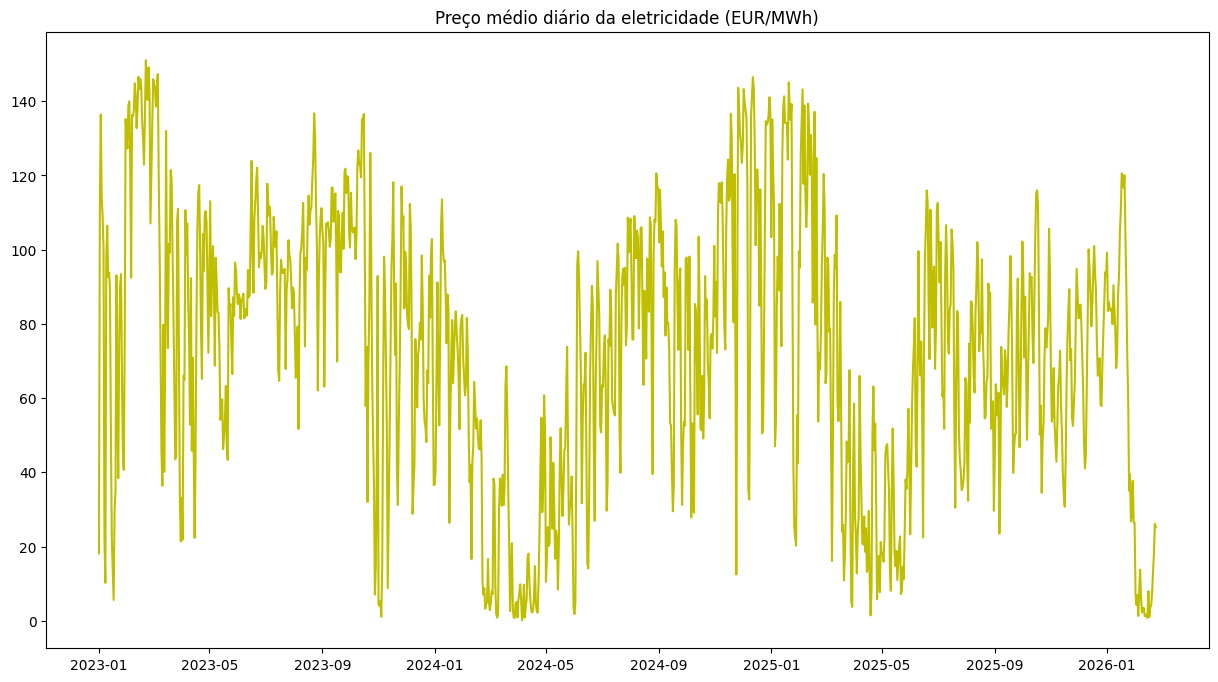

In [54]:
plt.figure(figsize=(15, 8))
plt.title('Preço médio diário da eletricidade (EUR/MWh)')
plt.plot(pd.to_datetime(df2['Data']),df2['avg_price_eur_mwh'] , color='y',)

<Axes: xlabel='avg_price_eur_mwh', ylabel='Count'>

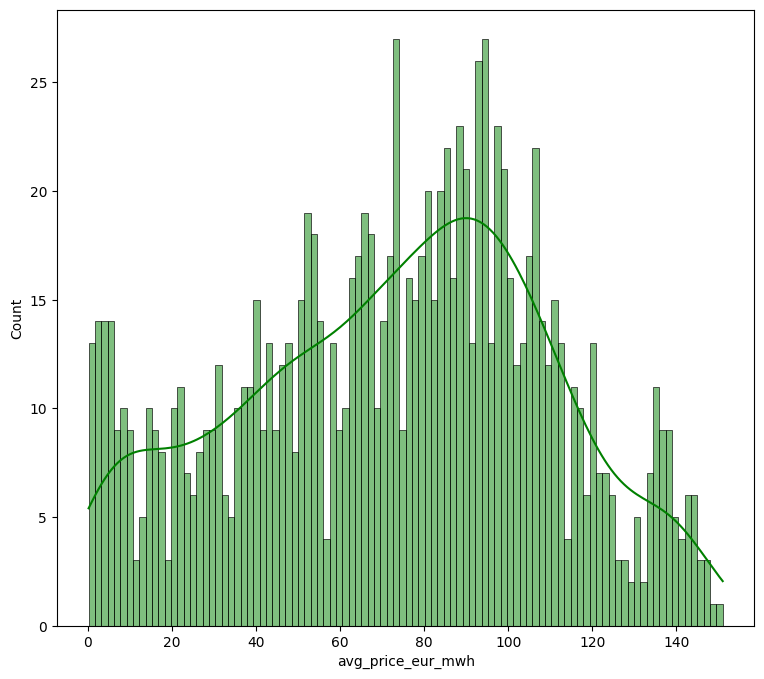

In [35]:
plt.figure(figsize=(9, 8))
sns.histplot(df2['avg_price_eur_mwh'], kde=True, color='g', bins=100, )

In [36]:
df2.loc[df2['avg_price_eur_mwh'] == df2['avg_price_eur_mwh'].max()]

,Data,Sunlight (em minutos),avg_price_eur_mwh,temp_C_mean,temp_C_min,temp_C_max,wind_speed_mean,wind_speed_min,wind_speed_max,precip_mm_sum,mean_cloud,min_cloud,max_cloud
51,2023-02-21,657.6,151.033333,12.05088,8.327087,16.856537,1.51781,0.158349,3.2261,0.128178,46.394405,23.323471,63.164997


In [43]:
df2.loc[df2['avg_price_eur_mwh'] == df2['avg_price_eur_mwh'].min()]

,Data,Sunlight (em minutos),avg_price_eur_mwh,temp_C_mean,temp_C_min,temp_C_max,wind_speed_mean,wind_speed_min,wind_speed_max,precip_mm_sum,mean_cloud,min_cloud,max_cloud
460,2024-04-05,772.2,0.146364,18.048113,10.626709,25.296265,4.49486,2.099352,6.624002,0.042587,97.81121,92.55996,99.99379


<Axes: xlabel='Total (kWh) (Consumido)', ylabel='Count'>

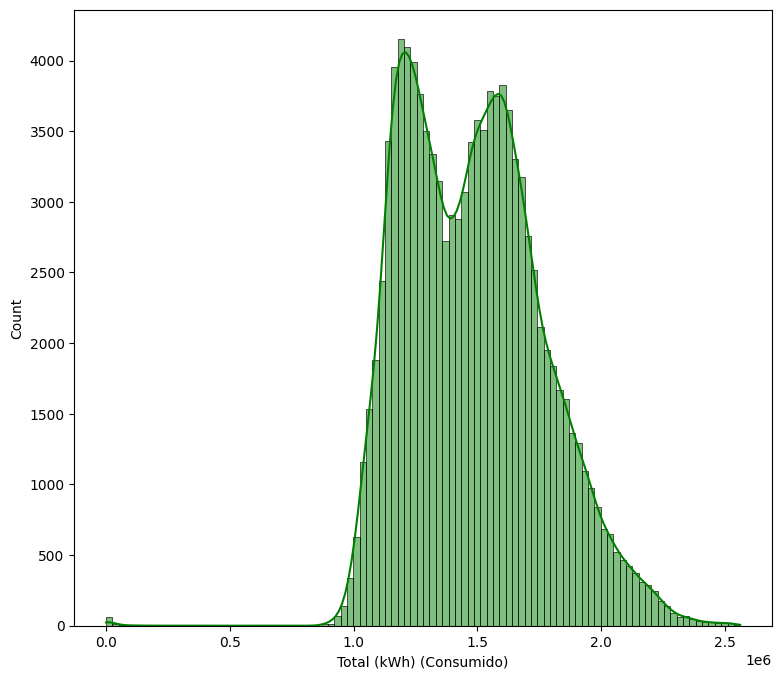

In [42]:
plt.figure(figsize=(9, 8))
sns.histplot(df['Total (kWh) (Consumido)'], kde=True, color='g', bins=100)

In [49]:
df.loc[df['Total (kWh) (Consumido)'] == df['Total (kWh) (Consumido)'].min()]

,Data/Hora,Cogeração (kWh),Eólica (kWh),Fotovoltaica (kWh),Hídrica (kWh),Outras Tecnologias (kWh),Rede Distribuição (kWh),Baixa Tensão (kWh),Média Tensão (kWh),Alta Tensão (kWh),Muito Alta Tensão (kWh),Dia,Mês,Ano,Data,Hora,Mercado (kWh),Regime Especial (kWh),Total (kWh) (Consumido),Total (kWh) (Produzido)
4951,2024-03-31T02:00:00+01:00,20951.25,265940.00,0.0,54961.50,80668.250,422521.000,0.0,0.0,0.0,0.0,31,3,2024,2024-03-31,01:00,0.0,0.000,0.0,0.000
4952,2024-03-31T02:00:00+01:00,20951.25,265940.00,0.0,54961.50,80668.250,422521.000,0.0,0.0,0.0,0.0,31,3,2024,2024-03-31,02:00,792754.0,422521.000,0.0,1215275.000
4955,2024-03-31T02:00:00+01:00,0.00,0.00,0.0,0.00,0.000,0.000,0.0,0.0,0.0,0.0,31,3,2024,2024-03-31,01:00,0.0,0.000,0.0,0.000
4956,2024-03-31T02:00:00+01:00,0.00,0.00,0.0,0.00,0.000,0.000,0.0,0.0,0.0,0.0,31,3,2024,2024-03-31,02:00,792754.0,422521.000,0.0,1215275.000
4961,2024-03-31T02:45:00+01:00,20272.50,259528.75,0.0,55001.00,84879.750,419682.000,0.0,0.0,0.0,0.0,31,3,2024,2024-03-31,02:45,717203.0,419682.000,0.0,1136885.000
4962,2024-03-31T02:45:00+01:00,20272.50,259528.75,0.0,55001.00,84879.750,419682.000,0.0,0.0,0.0,0.0,31,3,2024,2024-03-31,01:45,0.0,0.000,0.0,0.000
4965,2024-03-31T02:45:00+01:00,0.00,0.00,0.0,0.00,0.000,0.000,0.0,0.0,0.0,0.0,31,3,2024,2024-03-31,02:45,717203.0,419682.000,0.0,1136885.000
4966,2024-03-31T02:45:00+01:00,0.00,0.00,0.0,0.00,0.000,0.000,0.0,0.0,0.0,0.0,31,3,2024,2024-03-31,01:45,0.0,0.000,0.0,0.000
10127,2024-03-31T02:15:00+01:00,0.00,0.00,0.0,0.00,0.000,0.000,0.0,0.0,0.0,0.0,31,3,2024,2024-03-31,01:15,0.0,0.000,0.0,0.000
10128,2024-03-31T02:15:00+01:00,0.00,0.00,0.0,0.00,0.000,0.000,0.0,0.0,0.0,0.0,31,3,2024,2024-03-31,02:15,773801.0,414831.750,0.0,1188632.750


In [50]:
df.loc[df['Total (kWh) (Consumido)'] == df['Total (kWh) (Consumido)'].max()]

,Data/Hora,Cogeração (kWh),Eólica (kWh),Fotovoltaica (kWh),Hídrica (kWh),Outras Tecnologias (kWh),Rede Distribuição (kWh),Baixa Tensão (kWh),Média Tensão (kWh),Alta Tensão (kWh),Muito Alta Tensão (kWh),Dia,Mês,Ano,Data,Hora,Mercado (kWh),Regime Especial (kWh),Total (kWh) (Consumido),Total (kWh) (Produzido)
94597,2026-01-20T20:00:00+00:00,73466.5,686269.357,0.0,44699.25,42368.75,846803.857,1.727446e+06,568953.6155,217846.3708,47163.7955,20,1,2026,2026-01-20,20:00,1714606.0,846803.857,2.561410e+06,2561409.857


<Axes: xlabel='Sunlight (em minutos)', ylabel='Count'>

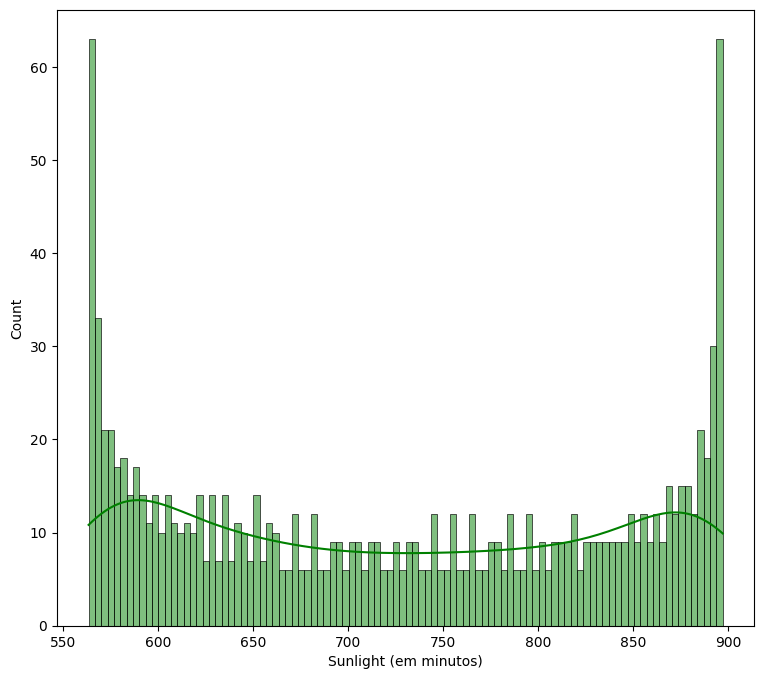

In [51]:
plt.figure(figsize=(9, 8))
sns.histplot(df2['Sunlight (em minutos)'], kde=True, color='g', bins=100)

<Axes: xlabel='precip_mm_sum', ylabel='Count'>

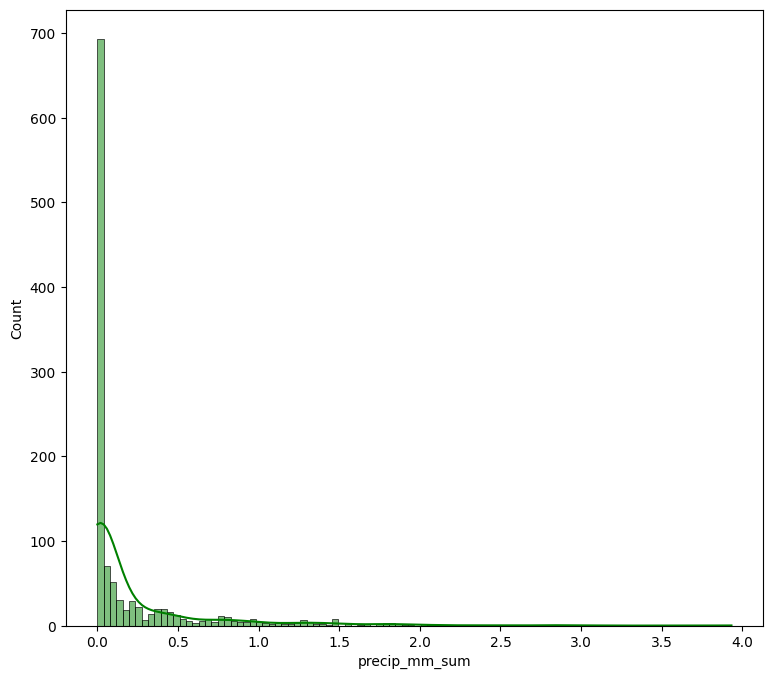

In [40]:
plt.figure(figsize=(9, 8))
sns.histplot(df2['precip_mm_sum'], kde=True, color='g', bins=100)

<Axes: xlabel='temp_C_mean', ylabel='Count'>

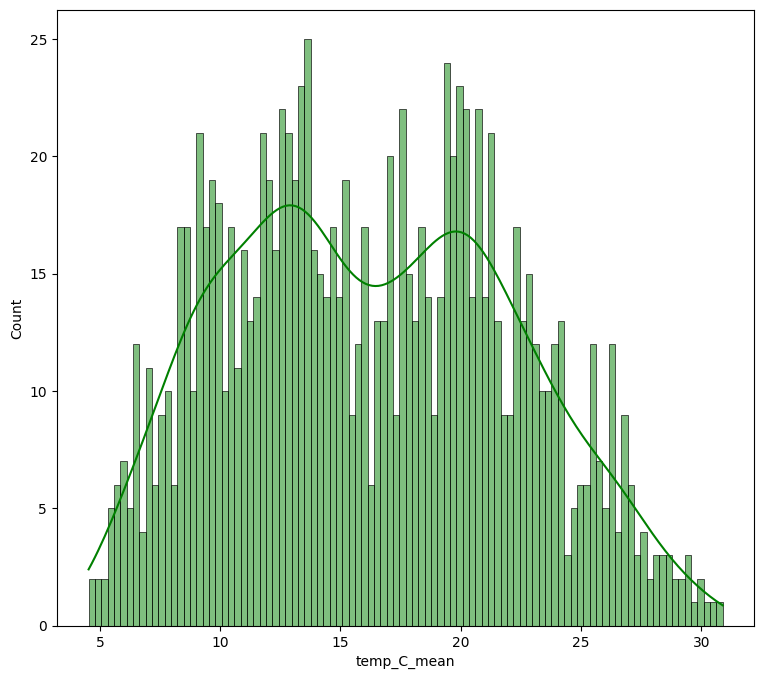

In [39]:
plt.figure(figsize=(9, 8))
sns.histplot(df2['temp_C_mean'], kde=True, color='g', bins=100)

<Axes: xlabel='wind_speed_mean', ylabel='Count'>

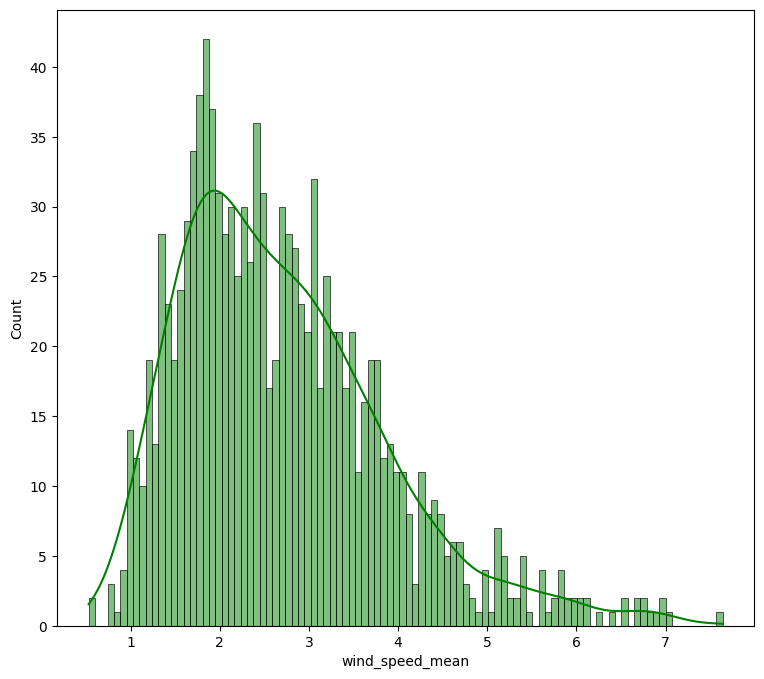

In [38]:
plt.figure(figsize=(9, 8))
sns.histplot(df2['wind_speed_mean'], kde=True, color='g', bins=100)

In [44]:
list(set(df.dtypes.tolist()))

[dtype('float64'), dtype('O'), dtype('int64')]

In [45]:
list(set(df2.dtypes.tolist()))

[dtype('float64'), dtype('O')]

In [46]:
df_num = df.select_dtypes(include = ['float64', 'int64'])
df_num.head()

,Cogeração (kWh),Eólica (kWh),Fotovoltaica (kWh),Hídrica (kWh),Outras Tecnologias (kWh),Rede Distribuição (kWh),Baixa Tensão (kWh),Média Tensão (kWh),Alta Tensão (kWh),Muito Alta Tensão (kWh),Dia,Mês,Ano,Mercado (kWh),Regime Especial (kWh),Total (kWh) (Consumido),Total (kWh) (Produzido)
0,65302.25,470343.00,0.0,15520.00,47144.841,598310.091,592532.955473,287985.9713,200478.7664,93272.4162,1,12,2024,575960.0,598310.091,1.174270e+06,1174270.091
1,66912.25,480471.25,0.0,15785.00,46545.885,609714.385,565779.817171,285096.4635,199081.6537,85699.4590,1,12,2024,525943.0,609714.385,1.135657e+06,1135657.385
2,66242.25,503178.50,0.0,14488.00,45818.386,629727.136,522073.741047,279149.8605,199194.3734,84687.1666,1,12,2024,455378.0,629727.136,1.085105e+06,1085105.136
3,66823.25,513665.25,0.0,14444.75,47138.854,642072.104,513901.486719,278234.8154,200238.9797,85355.8453,1,12,2024,435659.0,642072.104,1.077731e+06,1077731.104
4,66463.25,468322.00,0.0,13993.25,46508.978,595287.478,496285.574391,276626.0285,193322.8748,91739.0145,1,12,2024,462686.0,595287.478,1.057973e+06,1057973.478


array([[<Axes: title={'center': 'Cogeração (kWh)'}>,
        <Axes: title={'center': 'Eólica (kWh)'}>,
        <Axes: title={'center': 'Fotovoltaica (kWh)'}>,
        <Axes: title={'center': 'Hídrica (kWh)'}>],
       [<Axes: title={'center': 'Outras Tecnologias (kWh)'}>,
        <Axes: title={'center': 'Rede Distribuição (kWh)'}>,
        <Axes: title={'center': 'Baixa Tensão (kWh)'}>,
        <Axes: title={'center': 'Média Tensão (kWh)'}>],
       [<Axes: title={'center': 'Alta Tensão (kWh)'}>,
        <Axes: title={'center': 'Muito Alta Tensão (kWh)'}>,
        <Axes: title={'center': 'Dia'}>, <Axes: title={'center': 'Mês'}>],
       [<Axes: title={'center': 'Ano'}>,
        <Axes: title={'center': 'Mercado (kWh)'}>,
        <Axes: title={'center': 'Regime Especial (kWh)'}>,
        <Axes: title={'center': 'Total (kWh) (Consumido)'}>],
       [<Axes: title={'center': 'Total (kWh) (Produzido)'}>, <Axes: >,
        <Axes: >, <Axes: >]], dtype=object)

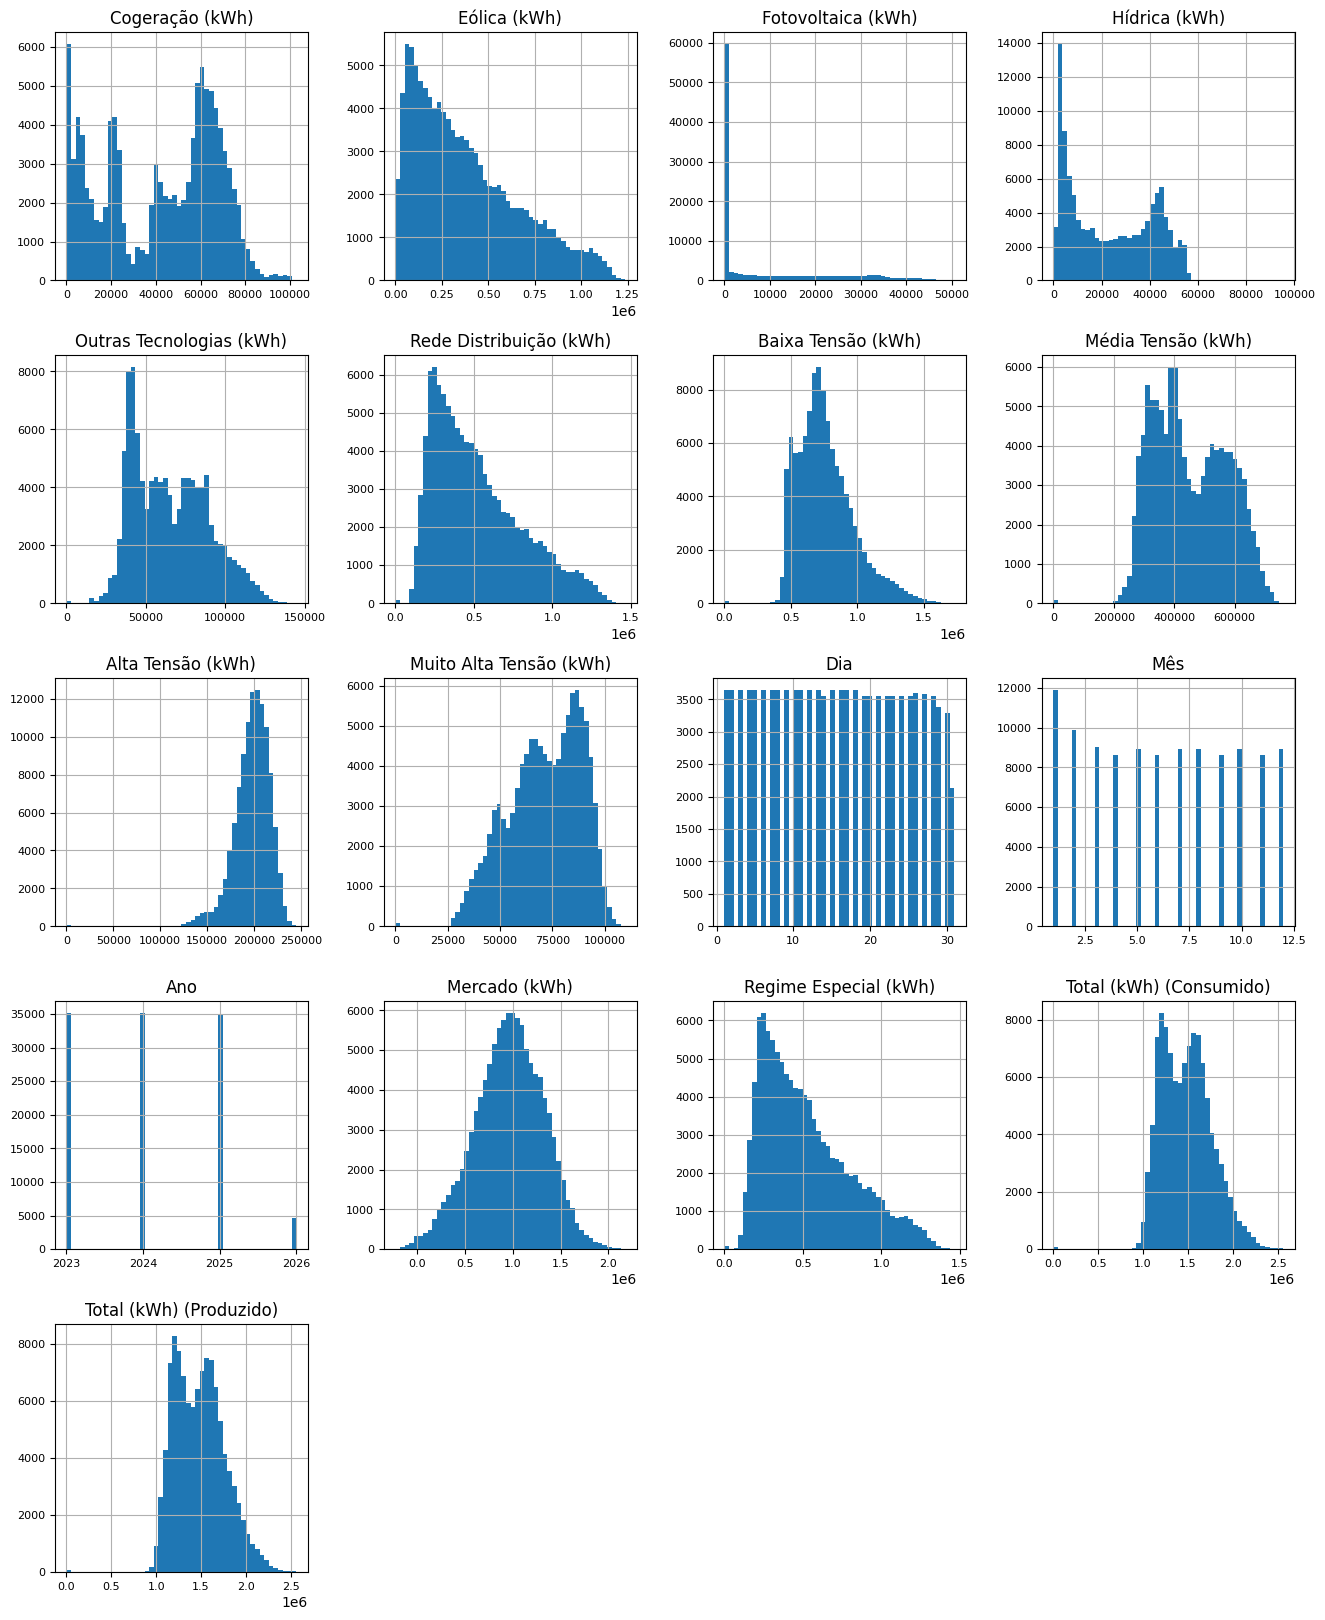

In [47]:
df_num.hist(figsize=(16, 20), bins=50, xlabelsize=8, ylabelsize=8)

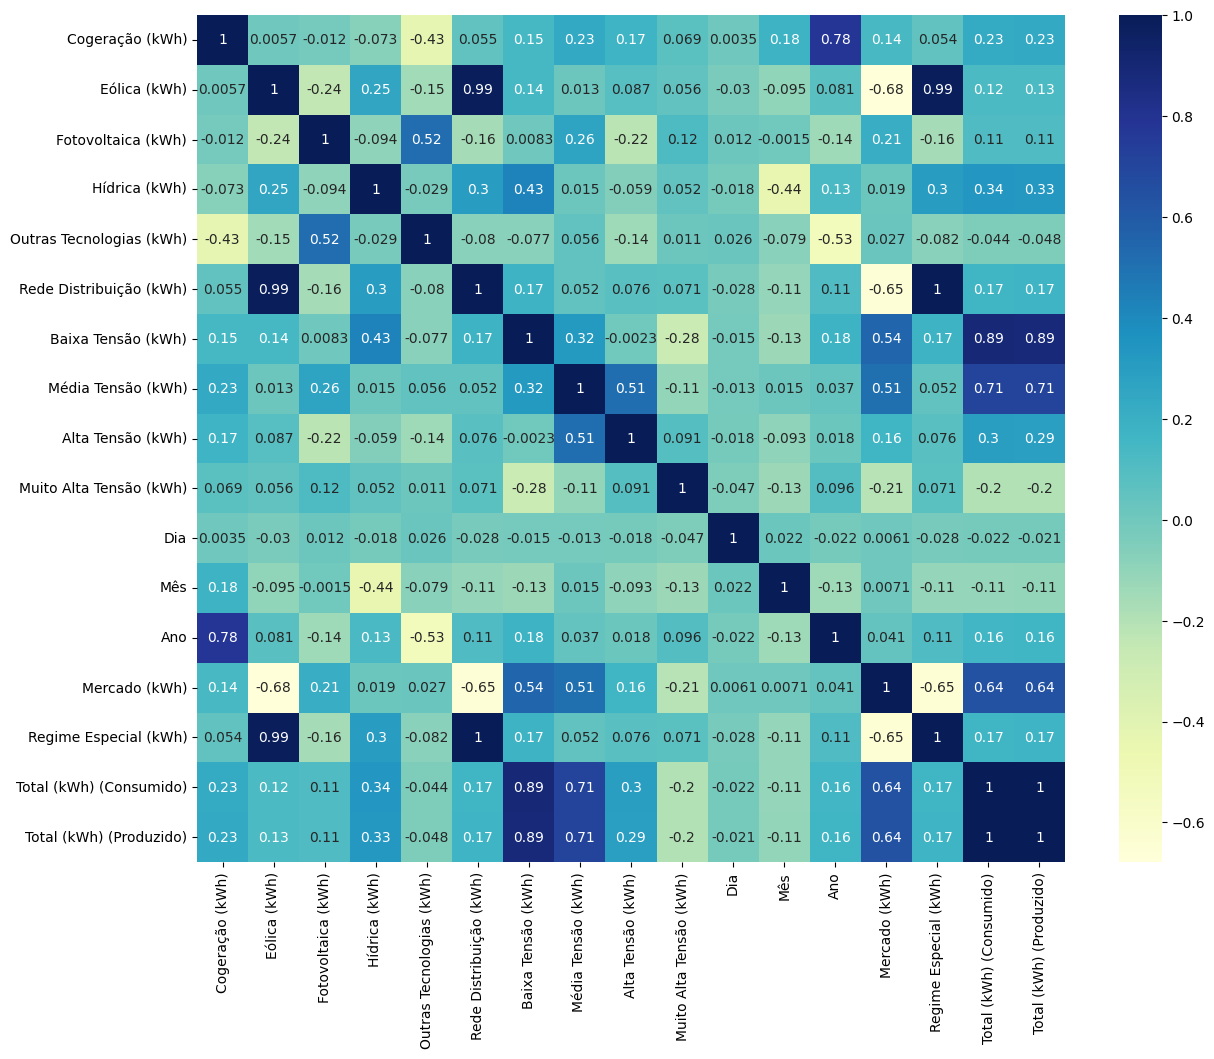

In [48]:
df_num_corr = df_num.corr()
plt.figure(figsize=(14, 11))
sns.heatmap(df_num_corr, cmap="YlGnBu", annot=True)

# Display heatmap
plt.show()

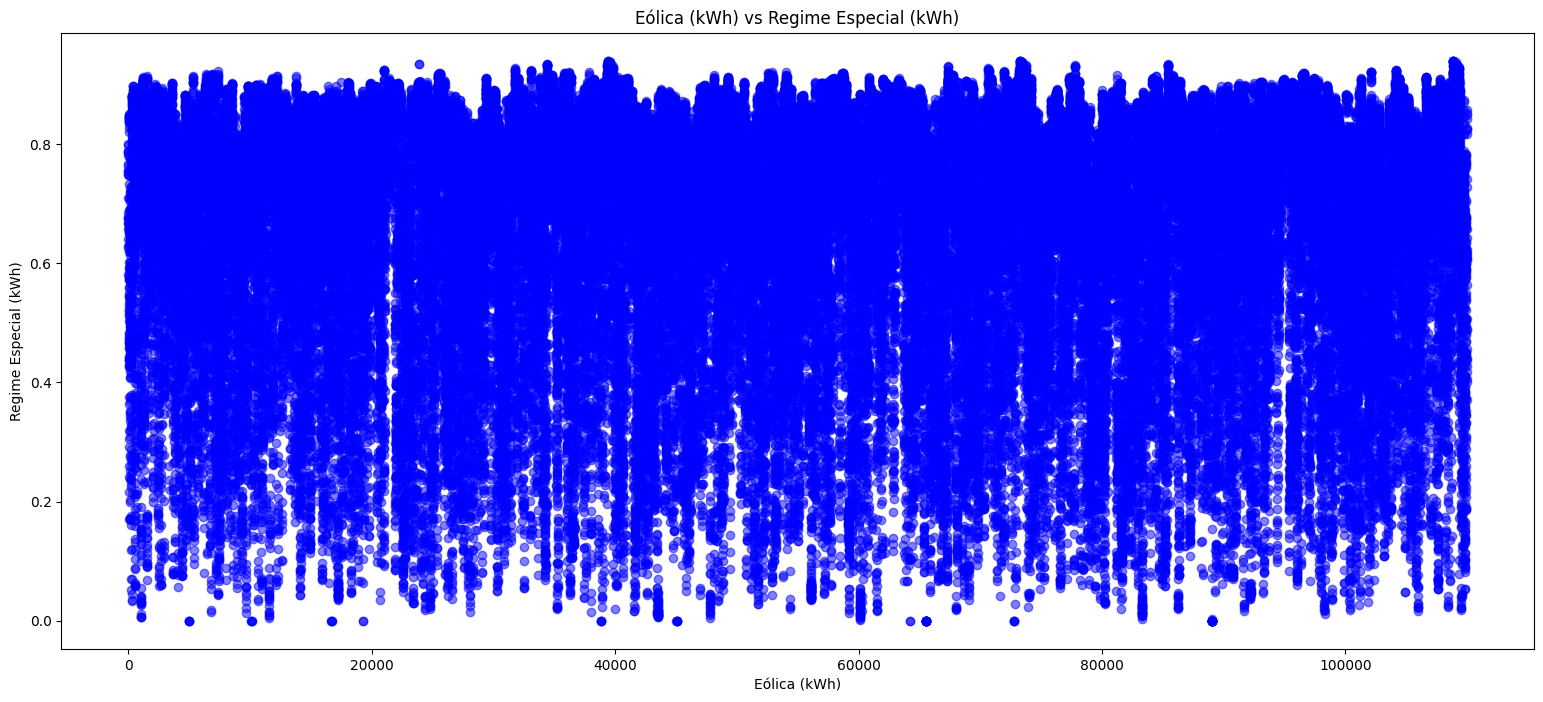

In [64]:
plt.figure(figsize=(19, 8))
plt.scatter(range(len(df)), df['Eólica (kWh)'] / df['Regime Especial (kWh)'], color='b', alpha=0.5)
plt.xlabel('Eólica (kWh)')
plt.ylabel('Regime Especial (kWh)')
plt.title('Eólica (kWh) vs Regime Especial (kWh)')
plt.show()

In [55]:
df2_num = df2.select_dtypes(include = ['float64', 'int64'])
df2_num.head()

,Sunlight (em minutos),avg_price_eur_mwh,temp_C_mean,temp_C_min,temp_C_max,wind_speed_mean,wind_speed_min,wind_speed_max,precip_mm_sum,mean_cloud,min_cloud,max_cloud
0,566.4,18.194000,13.957454,10.834991,16.947662,4.481200,2.297339,5.367133,1.269626,74.777596,52.815266,99.949486
1,567.0,111.630000,9.369559,6.194458,13.110443,1.754022,1.328135,2.657617,0.001833,54.611576,2.995821,98.287170
2,568.2,136.436667,7.013123,2.730926,12.917389,1.954998,1.635701,2.475706,0.000043,20.363108,5.319932,36.422657
3,568.8,114.217917,7.858103,3.627960,14.481567,2.123019,1.683161,2.530171,0.000680,12.962455,0.111874,32.494614
4,570.0,109.020833,8.435746,4.148926,14.648651,1.493893,0.380866,2.170711,0.000315,4.253893,0.000000,11.968743


array([[<Axes: title={'center': 'Sunlight (em minutos)'}>,
        <Axes: title={'center': 'avg_price_eur_mwh'}>,
        <Axes: title={'center': 'temp_C_mean'}>],
       [<Axes: title={'center': 'temp_C_min'}>,
        <Axes: title={'center': 'temp_C_max'}>,
        <Axes: title={'center': 'wind_speed_mean'}>],
       [<Axes: title={'center': 'wind_speed_min'}>,
        <Axes: title={'center': 'wind_speed_max'}>,
        <Axes: title={'center': 'precip_mm_sum'}>],
       [<Axes: title={'center': 'mean_cloud'}>,
        <Axes: title={'center': 'min_cloud'}>,
        <Axes: title={'center': 'max_cloud'}>]], dtype=object)

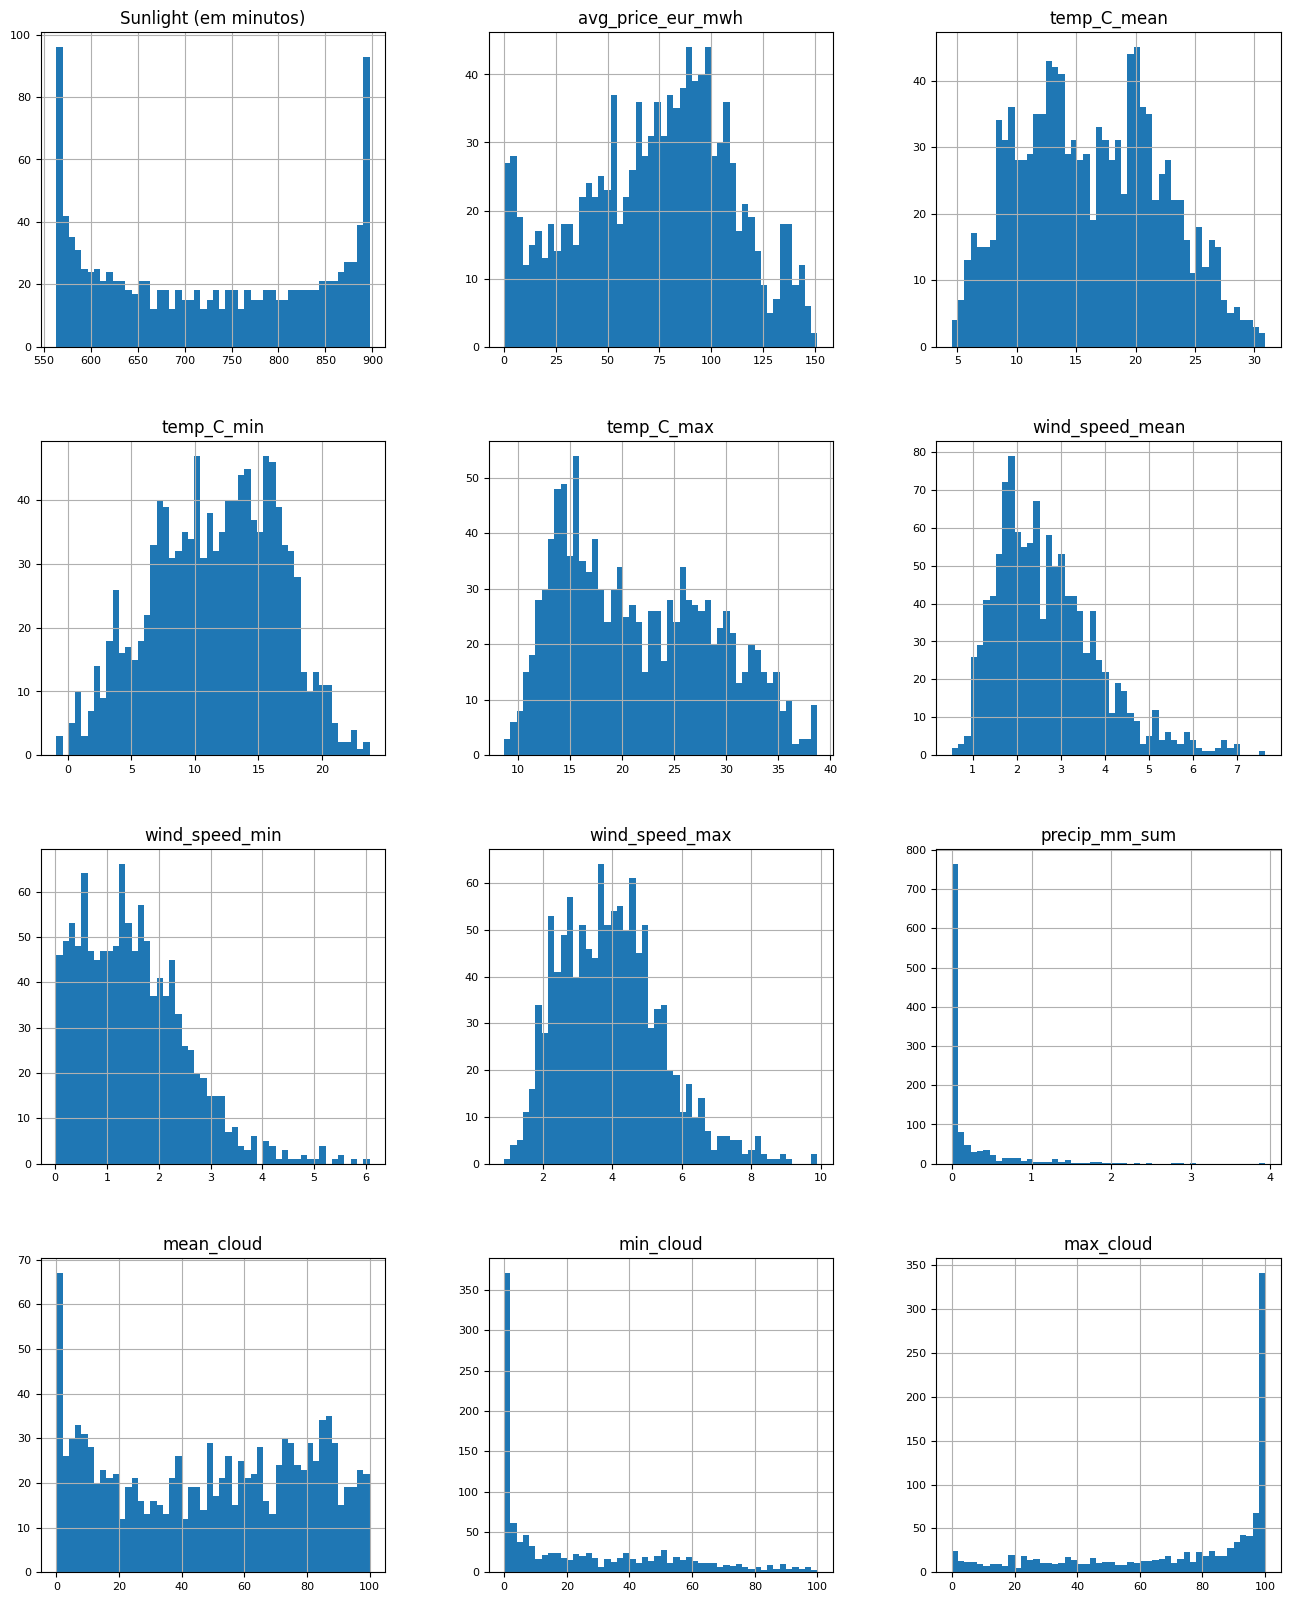

In [56]:
df2_num.hist(figsize=(16, 20), bins=50, xlabelsize=8, ylabelsize=8)

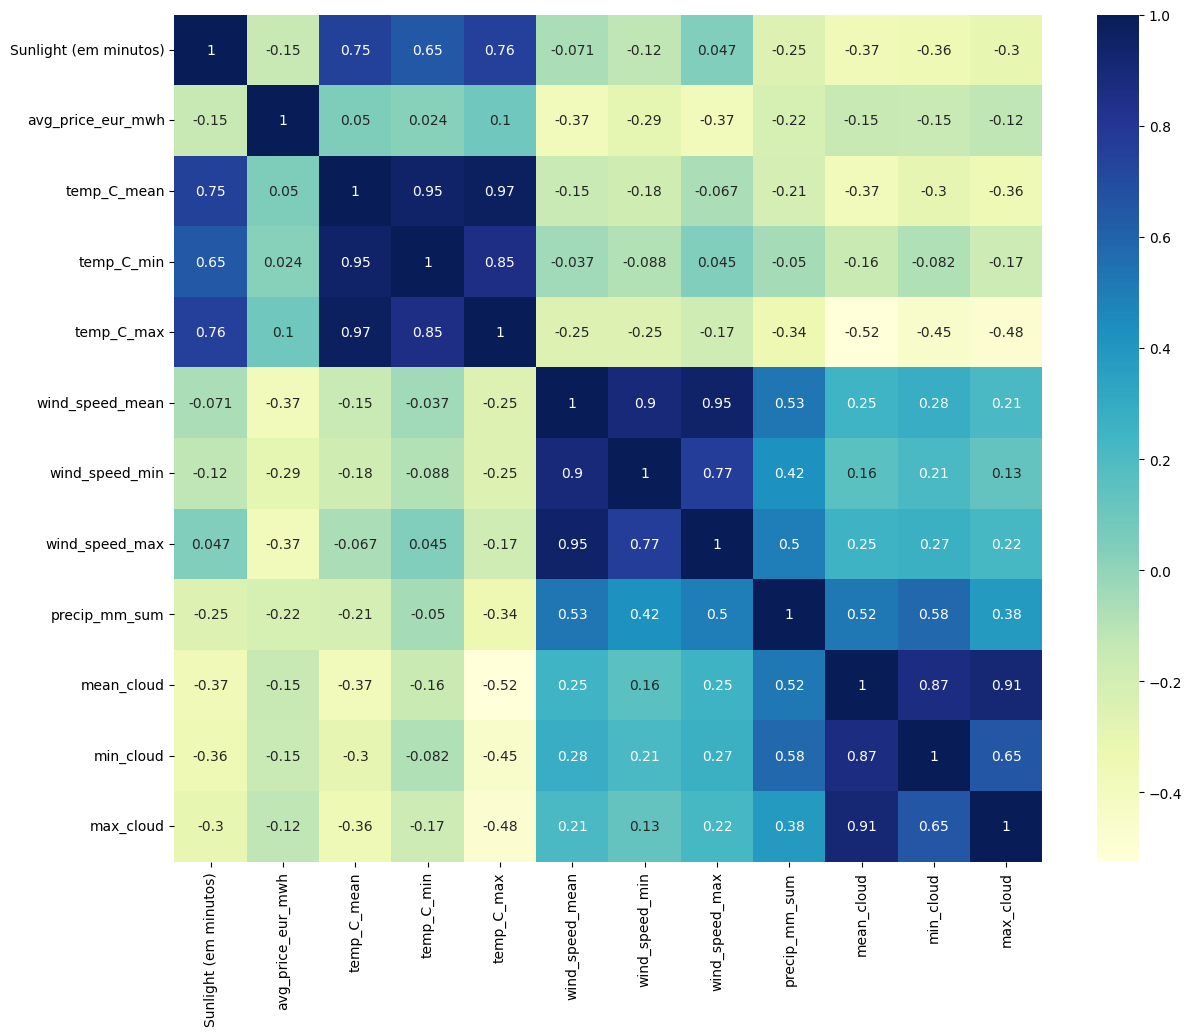

In [65]:
df2_num_corr = df2_num.corr()
plt.figure(figsize=(14, 11))
sns.heatmap(df2_num_corr, cmap="YlGnBu", annot=True)

# Display heatmap
plt.show()

<Figure size 1800x1500 with 0 Axes>

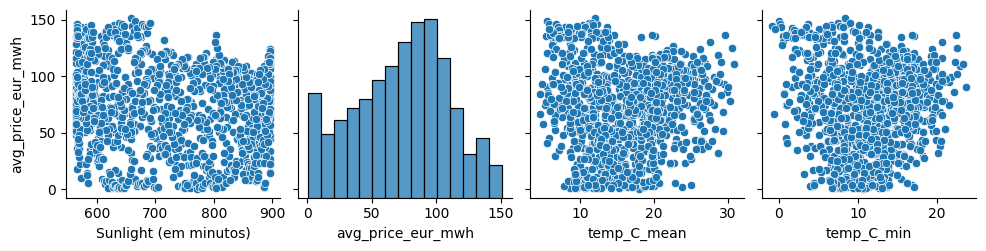

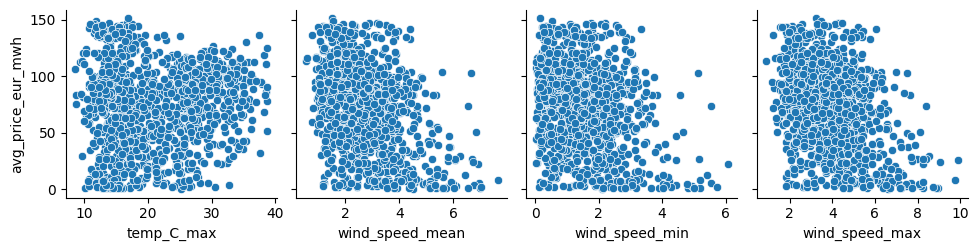

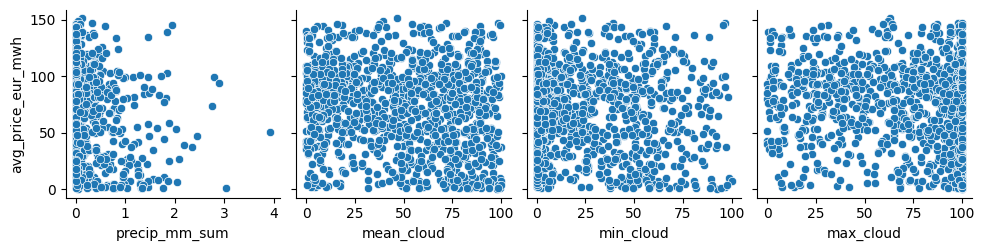

In [68]:
plt.figure(figsize=(18, 15))
for i in range(0, len(df2_num.columns), 4):
    sns.pairplot(data=df2_num,
                x_vars=df2_num.columns[i:i+4],
                y_vars=['avg_price_eur_mwh'])

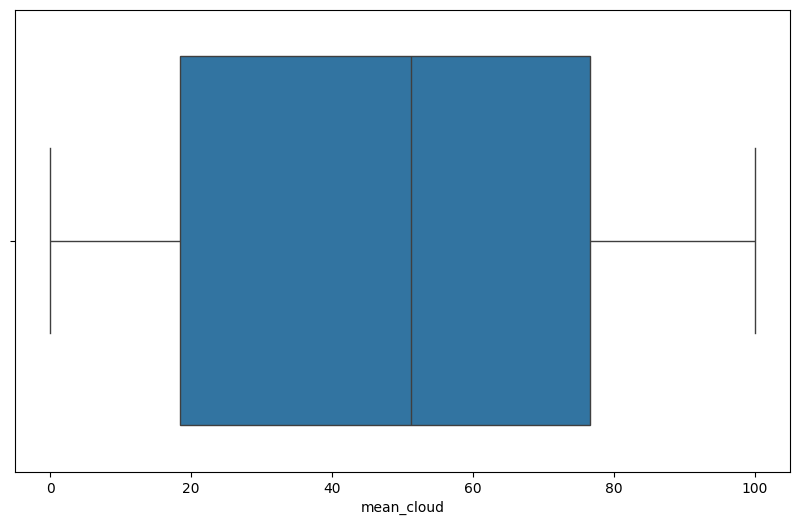

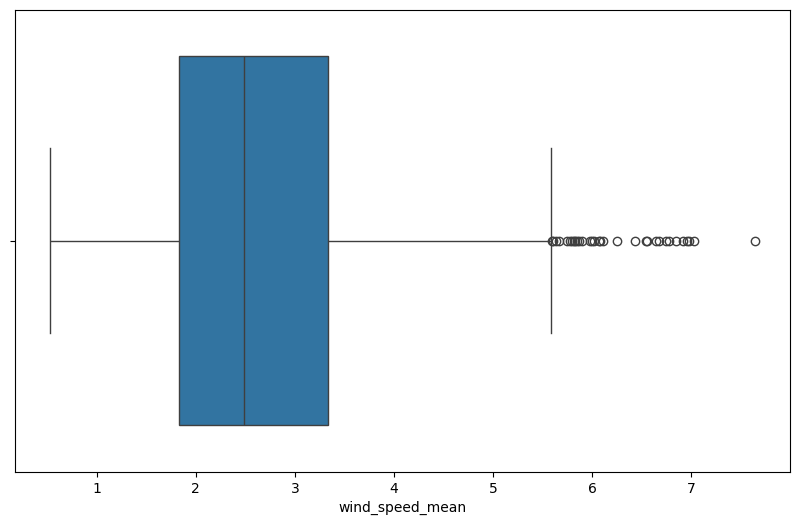

In [67]:
plt.figure(figsize=(10, 6))
sns.boxplot(x=df2.loc[:,"mean_cloud"])
plt.show()
plt.figure(figsize=(10, 6))
sns.boxplot(x=df2.loc[:,"wind_speed_mean"])
plt.show()

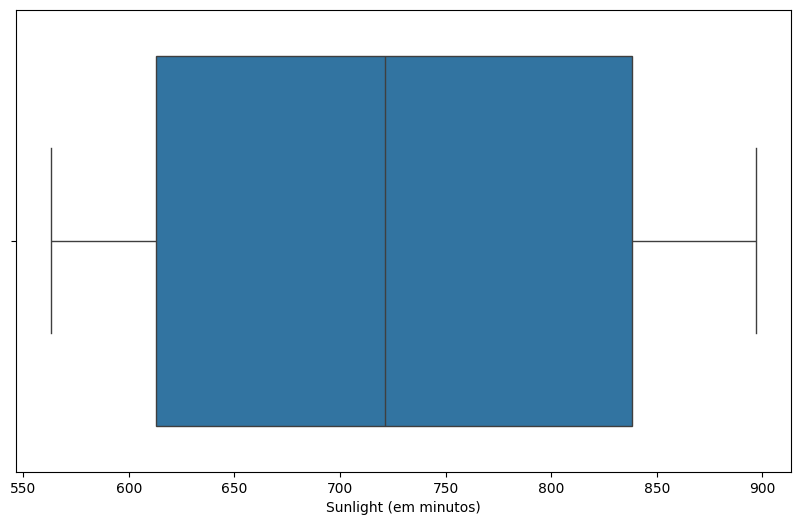

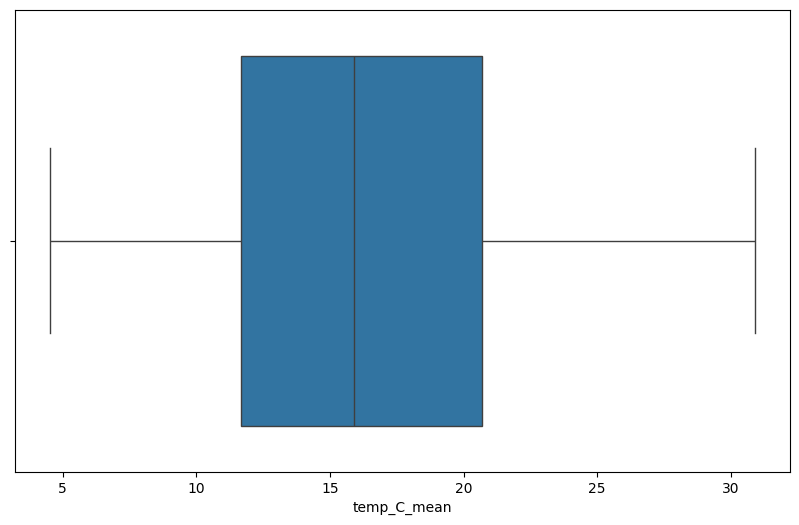

In [69]:
plt.figure(figsize=(10, 6))
sns.boxplot(x=df2.loc[:,"Sunlight (em minutos)"])
plt.show()
plt.figure(figsize=(10, 6))
sns.boxplot(x=df2.loc[:,"temp_C_mean"])
plt.show()

## Pré-processamento

In [59]:
falta_dados = {k:0 for k in df2['Data']}

In [60]:
start_date = "2023-01-01 00:00"
end_date = "2026-02-19 00:00" 
intervalos = pd.DataFrame({'timestamps': pd.date_range(start=start_date, end=end_date, freq='15min', tz='UTC')})
intervalos['dia'] = intervalos['timestamps'].dt.strftime('%Y-%m-%d')
intervalos.head()

,timestamps,dia
0,2023-01-01 00:00:00+00:00,2023-01-01
1,2023-01-01 00:15:00+00:00,2023-01-01
2,2023-01-01 00:30:00+00:00,2023-01-01
3,2023-01-01 00:45:00+00:00,2023-01-01
4,2023-01-01 01:00:00+00:00,2023-01-01


In [61]:
data_clean = pd.to_datetime(df['Data/Hora'])

# 2. O seu objeto 'intervalos' já é, por natureza, um datetime (graças ao date_range)
# NÃO converta para string. Compare o objeto datetime com o objeto datetime.
mask = ~intervalos['timestamps'].isin(data_clean)
# 3. Resultado
datas = intervalos.loc[mask,'dia']
horas = intervalos.loc[mask,'timestamps']
horas_l = []
for data,hora in zip(datas,horas):
    falta_dados[data]+=1
    horas_l.append(hora)
print(intervalos.loc[mask,'timestamps'])

print(f"Valores em falta: {mask.sum()}")

28896   2023-10-29 00:00:00+00:00
28897   2023-10-29 00:15:00+00:00
28898   2023-10-29 00:30:00+00:00
28899   2023-10-29 00:45:00+00:00
63840   2024-10-27 00:00:00+00:00
                   ...           
97724   2025-10-14 23:00:00+00:00
98784   2025-10-26 00:00:00+00:00
98785   2025-10-26 00:15:00+00:00
98786   2025-10-26 00:30:00+00:00
98787   2025-10-26 00:45:00+00:00
Name: timestamps, Length: 108, dtype: datetime64[ns, UTC]
Valores em falta: 108


C:\Users\Henrique\AppData\Local\Temp\ipykernel_27328\86150707.py:1: FutureWarning: In a future version of pandas, parsing datetimes with mixed time zones will raise an error unless `utc=True`. Please specify `utc=True` to opt in to the new behaviour and silence this warning. To create a `Series` with mixed offsets and `object` dtype, please use `apply` and `datetime.datetime.strptime`
  data_clean = pd.to_datetime(df['Data/Hora'])


In [62]:
horas_l

[Timestamp('2023-10-29 00:00:00+0000', tz='UTC'),
 Timestamp('2023-10-29 00:15:00+0000', tz='UTC'),
 Timestamp('2023-10-29 00:30:00+0000', tz='UTC'),
 Timestamp('2023-10-29 00:45:00+0000', tz='UTC'),
 Timestamp('2024-10-27 00:00:00+0000', tz='UTC'),
 Timestamp('2024-10-27 00:15:00+0000', tz='UTC'),
 Timestamp('2024-10-27 00:30:00+0000', tz='UTC'),
 Timestamp('2024-10-27 00:45:00+0000', tz='UTC'),
 Timestamp('2025-10-13 23:15:00+0000', tz='UTC'),
 Timestamp('2025-10-13 23:30:00+0000', tz='UTC'),
 Timestamp('2025-10-13 23:45:00+0000', tz='UTC'),
 Timestamp('2025-10-14 00:00:00+0000', tz='UTC'),
 Timestamp('2025-10-14 00:15:00+0000', tz='UTC'),
 Timestamp('2025-10-14 00:30:00+0000', tz='UTC'),
 Timestamp('2025-10-14 00:45:00+0000', tz='UTC'),
 Timestamp('2025-10-14 01:00:00+0000', tz='UTC'),
 Timestamp('2025-10-14 01:15:00+0000', tz='UTC'),
 Timestamp('2025-10-14 01:30:00+0000', tz='UTC'),
 Timestamp('2025-10-14 01:45:00+0000', tz='UTC'),
 Timestamp('2025-10-14 02:00:00+0000', tz='UTC'),


In [57]:
intervalos.loc[intervalos['dia']=='2024-10-11',:].shape

(96, 2)

In [50]:
falta_dados

{'2023-01-01': 0,
 '2023-01-02': 0,
 '2023-01-03': 0,
 '2023-01-04': 0,
 '2023-01-05': 0,
 '2023-01-06': 0,
 '2023-01-07': 0,
 '2023-01-08': 0,
 '2023-01-09': 0,
 '2023-01-10': 0,
 '2023-01-11': 0,
 '2023-01-12': 0,
 '2023-01-13': 0,
 '2023-01-14': 0,
 '2023-01-15': 0,
 '2023-01-16': 0,
 '2023-01-17': 0,
 '2023-01-18': 0,
 '2023-01-19': 0,
 '2023-01-20': 0,
 '2023-01-21': 0,
 '2023-01-22': 0,
 '2023-01-23': 0,
 '2023-01-24': 0,
 '2023-01-25': 0,
 '2023-01-26': 0,
 '2023-01-27': 0,
 '2023-01-28': 0,
 '2023-01-29': 0,
 '2023-01-30': 0,
 '2023-01-31': 0,
 '2023-02-01': 0,
 '2023-02-02': 0,
 '2023-02-03': 0,
 '2023-02-04': 0,
 '2023-02-05': 0,
 '2023-02-06': 0,
 '2023-02-07': 0,
 '2023-02-08': 0,
 '2023-02-09': 0,
 '2023-02-10': 0,
 '2023-02-11': 0,
 '2023-02-12': 0,
 '2023-02-13': 0,
 '2023-02-14': 0,
 '2023-02-15': 0,
 '2023-02-16': 0,
 '2023-02-17': 0,
 '2023-02-18': 0,
 '2023-02-19': 0,
 '2023-02-20': 0,
 '2023-02-21': 0,
 '2023-02-22': 0,
 '2023-02-23': 0,
 '2023-02-24': 0,
 '2023-02-

In [ ]:
falta_dados = {k:v for k,v in falta_dados.items() if v!=0 }

In [ ]:
json_str = json.dumps(falta_dados, indent=4)
with open("dias_n_falta(96total).json", "w") as f:
    f.write(json_str)

In [63]:
df.shape

(109981, 21)

In [65]:
df = df.loc[df['Data']!='2025-10-14',:]
df.shape

(109980, 21)